# Evaluasi Final Penelitian Edge–Cloud dan Digital Twin Web-3D

**Judul penelitian:** Arsitektur Edge-Cloud untuk Estimasi Daya Near Real-Time Bangunan Cerdas Terintegrasi Digital Twin Web-3D

Notebook ini menyajikan hasil eksperimen final dalam format yang mudah dibaca dan dapat dijalankan ulang. Angka diambil dari artefak `results/final/`; notebook ini tidak melatih ulang model secara otomatis.

**Posisi tiga sumber data:** 92.160 baris asli untuk kalibrasi; 493.700 baris sintetis terkalibrasi untuk train–validation–test estimator; dan 2.027.520 baris augmented sebagai 22 blok workload replay untuk benchmark edge-cloud serta demonstrasi Digital Twin Web-3D.

> **Batas klaim:** hasil merupakan evaluasi berbasis simulasi yang dikalibrasi dari trace sensor nyata. Hasil bukan validasi lapangan, pengukuran Raspberry Pi baru, atau pengukuran public cloud.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option('display.max_colwidth', 120)
pd.options.display.float_format = '{:,.3f}'.format

# Tetap bekerja jika notebook dibuka dari root proyek atau folder notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'results' / 'final').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
RESULTS_DIR = PROJECT_ROOT / 'results' / 'final'
FIGURES_DIR = RESULTS_DIR / 'figures'

assert RESULTS_DIR.exists(), f'Folder hasil tidak ditemukan: {RESULTS_DIR}'
print(f'Root proyek : {PROJECT_ROOT}')
print(f'Hasil final : {RESULTS_DIR}')

Root proyek : /Users/macbookpro/Documents/jurnal_penelitian
Hasil final : /Users/macbookpro/Documents/jurnal_penelitian/results/final


In [2]:
def load_json(filename):
    with (RESULTS_DIR / filename).open(encoding='utf-8') as file:
        return json.load(file)

summary = load_json('experiment_summary.json')
trace = load_json('trace_audit.json')
synthetic = load_json('synthetic_validation.json')
models = load_json('model_metrics.json')
benchmark = load_json('benchmark_metrics.json')
augmented = load_json('augmented_workload_audit.json')

display(pd.DataFrame([
    ['Status pipeline', summary['pipeline_status']],
    ['Jenis eksperimen', summary['run_type']],
    ['Jumlah data sintetis', f"{summary['rows']:,} baris"],
    ['Jumlah run', summary['runs']],
    ['Workload augmented', f"{augmented['source']['rows']:,} baris / {augmented['provenance']['inferred_replay_blocks']:.0f} replay"],
    ['Model terpilih', models['model_selection']['selected_model'].title()],
], columns=['Komponen', 'Nilai']).style.hide(axis='index'))

Komponen,Nilai
Status pipeline,completed
Jenis eksperimen,final_configured_experiment
Jumlah data sintetis,"493,700 baris"
Jumlah run,20
Workload augmented,"2,027,520 baris / 22 replay"
Model terpilih,Ridge


## 1. Audit data sensor asli

Workbook asli dipakai sebagai **trace kalibrasi**, bukan sebagai ground truth daya aktif independen. Kolom daya historis dihitung oleh firmware menggunakan tegangan × arus tanpa pengukuran faktor daya.

In [3]:
source = trace['source']
sampling = trace['sampling']
audit_table = pd.DataFrame([
    ['File sumber', source['path']],
    ['Jumlah baris', f"{source['rows']:,}"],
    ['Jumlah perangkat/gateway', source['device_count']],
    ['Rentang timestamp', f"{source['timestamp_start_utc']} sampai {source['timestamp_end_utc']}"],
    ['Timestamp duplikat', source['duplicate_timestamps']],
    ['Interval median', f"{sampling['gap_seconds_p50']:.3f} detik"],
    ['Interval P95', f"{sampling['gap_seconds_p95']:.3f} detik"],
    ['SHA-256', source['sha256']],
], columns=['Pemeriksaan', 'Hasil'])
display(audit_table.style.hide(axis='index'))

Pemeriksaan,Hasil
File sumber,Data/sensor_data_export_2026-05-17_to_2026-05-23.xlsx
Jumlah baris,"92,160"
Jumlah perangkat/gateway,1
Rentang timestamp,2026-05-19T17:10:55.418478500+00:00 sampai 2026-05-23T18:22:06.727676100+00:00
Timestamp duplikat,0
Interval median,3.525 detik
Interval P95,5.102 detik
SHA-256,dd8b5028eda7bca0265da4ada881e1ed1f1ec84afb6b6f0a33cd82f9984f4d29


## 2. Kalibrasi dan validasi diagnostik data sintetis

Skenario sintetis `normal` dibandingkan dengan trace asli melalui kuantil, proporsi nilai nol, dan autokorelasi lag-1. Kelulusan di bagian ini berarti karakteristik statistik yang diperiksa berada dalam toleransi yang ditetapkan; **bukan berarti data sintetis berubah menjadi data nyata**.

In [4]:
comparison = synthetic['calibration_comparison']
criteria = comparison['acceptance_criteria']['by_variable']
calibration_rows = []
for variable, values in comparison['variables'].items():
    calibration_rows.append({
        'Variabel': variable,
        'Normalized quantile MAE': values['normalized_quantile_mae'],
        'Galat zero-rate': abs(values['real_zero_rate'] - values['synthetic_zero_rate']),
        'Galat ACF lag-1': abs(values['real_acf_lag_1'] - values['synthetic_acf_lag_1']),
        'Status': 'Lulus' if criteria[variable]['accepted'] else 'Tidak lulus',
    })

calibration_df = pd.DataFrame(calibration_rows)
display(calibration_df.style.hide(axis='index').format({
    'Normalized quantile MAE': '{:.3f}',
    'Galat zero-rate': '{:.3f}',
    'Galat ACF lag-1': '{:.3f}',
}))

overall_calibration = comparison['acceptance_criteria']['overall_accepted']
display(Markdown(f"**Status kalibrasi keseluruhan: {'LULUS' if overall_calibration else 'TIDAK LULUS'}**"))

Variabel,Normalized quantile MAE,Galat zero-rate,Galat ACF lag-1,Status
temperature_c,0.064,0.000,0.023,Lulus
humidity_pct,0.032,0.000,0.005,Lulus
voltage_v,0.006,0.001,0.018,Lulus
current_a,0.023,0.011,0.046,Lulus
power_w,0.011,0.001,0.002,Lulus
people_count,0.000,0.017,0.000,Lulus


**Status kalibrasi keseluruhan: LULUS**

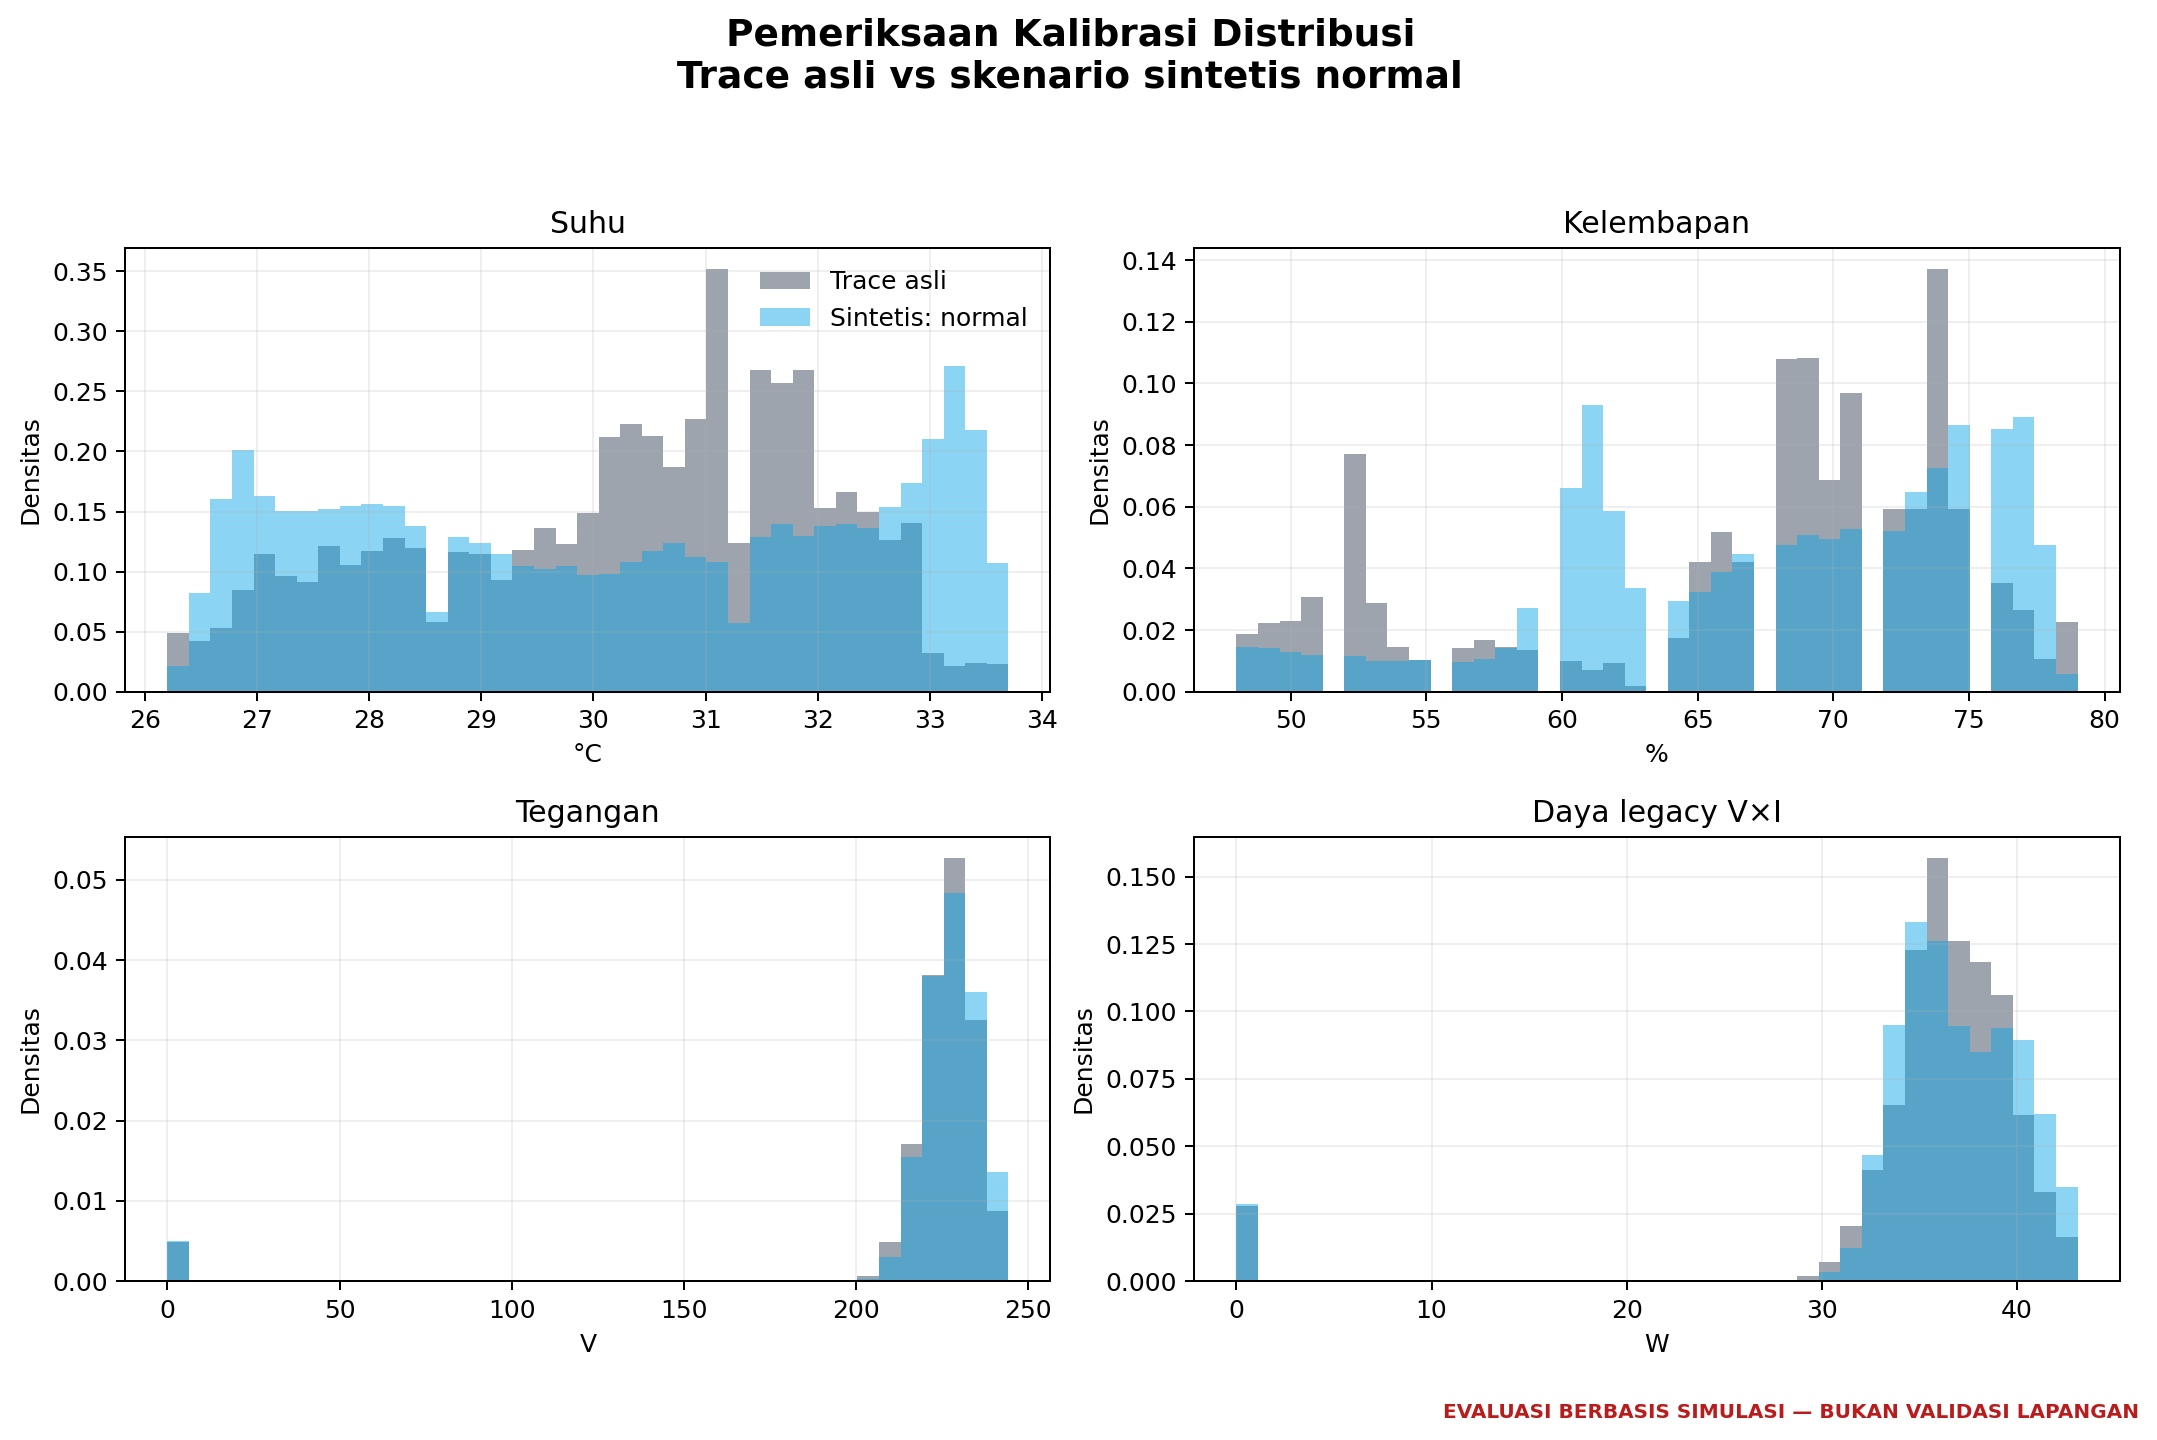

In [5]:
display(Image(filename=str(FIGURES_DIR / '01_calibration_distribution.png')))

## 3. Desain train–validation–test

Pemisahan dilakukan berdasarkan skenario dan run, bukan random row split. Model dipilih menggunakan validation MAE. Test set yang ditahan tidak digunakan untuk memilih model.

In [6]:
design = models['evaluation_design']
split_df = pd.DataFrame([
    ['Training', ', '.join(design['train_scenarios']), design['train_rows'], len(design['train_runs'])],
    ['Validation', ', '.join(design['validation_scenarios']), design['validation_rows'], len(design['validation_runs'])],
    ['Test tertahan', ', '.join(design['test_scenarios']), design['test_rows'], len(design['test_runs'])],
], columns=['Split', 'Skenario', 'Baris', 'Run'])
display(split_df.style.hide(axis='index').format({'Baris': '{:,.0f}'}))
display(Markdown(
    f"**Kriteria pemilihan:** {models['model_selection']['criterion']}; "
    f"**model terpilih: {models['model_selection']['selected_model'].title()}**."
))

Split,Skenario,Baris,Run
Training,"hot_busy, normal","197,152",8
Validation,humid_unstable,"98,368",4
Test tertahan,"cool_low_load, sensor_degraded","196,213",8


**Kriteria pemilihan:** lowest validation MAE; **model terpilih: Ridge**.

## 4. Hasil semua model pada test set tertahan

Angka utama berikut adalah rata-rata dari delapan run pengujian dengan 95% confidence interval. R² menunjukkan proporsi variasi target yang dapat dijelaskan, **bukan persentase akurasi**. R² negatif berarti model lebih buruk daripada prediksi konstan menggunakan rata-rata target.

In [7]:
MODEL_LABELS = {
    'constant_train_median': 'Median train',
    'firmware_v_times_i': 'Firmware V×I',
    'ridge': 'Ridge',
    'random_forest': 'Random Forest',
}

def ci_text(metric, unit=''):
    suffix = f' {unit}' if unit else ''
    return f"{metric['mean']:.3f}{suffix} [{metric['ci95_low']:.3f}, {metric['ci95_high']:.3f}]"

model_rows = []
for model_id, result in models['metrics'].items():
    run = result['run_level_summary']
    model_rows.append({
        'Model': MODEL_LABELS[model_id],
        'MAE [95% CI]': ci_text(run['mae_w'], 'W'),
        'RMSE [95% CI]': ci_text(run['rmse_w'], 'W'),
        'R² [95% CI]': ci_text(run['r2']),
        'R² rata-rata (%)': 100 * run['r2']['mean'],
    })

model_df = pd.DataFrame(model_rows)
display(model_df.style.hide(axis='index').format({'R² rata-rata (%)': '{:.1f}%'}))

Model,MAE [95% CI],RMSE [95% CI],R² [95% CI],R² rata-rata (%)
Median train,"6.855 W [4.074, 9.636]","7.267 W [4.652, 9.882]","-14.822 [-25.354, -4.291]",-1482.2%
Firmware V×I,"3.154 W [2.322, 3.986]","8.687 W [6.598, 10.777]","-13.413 [-17.732, -9.095]",-1341.3%
Ridge,"1.277 W [1.196, 1.359]","1.748 W [1.591, 1.904]","0.357 [0.124, 0.589]",35.7%
Random Forest,"2.306 W [1.600, 3.012]","2.667 W [1.994, 3.339]","-0.844 [-1.901, 0.214]",-84.4%


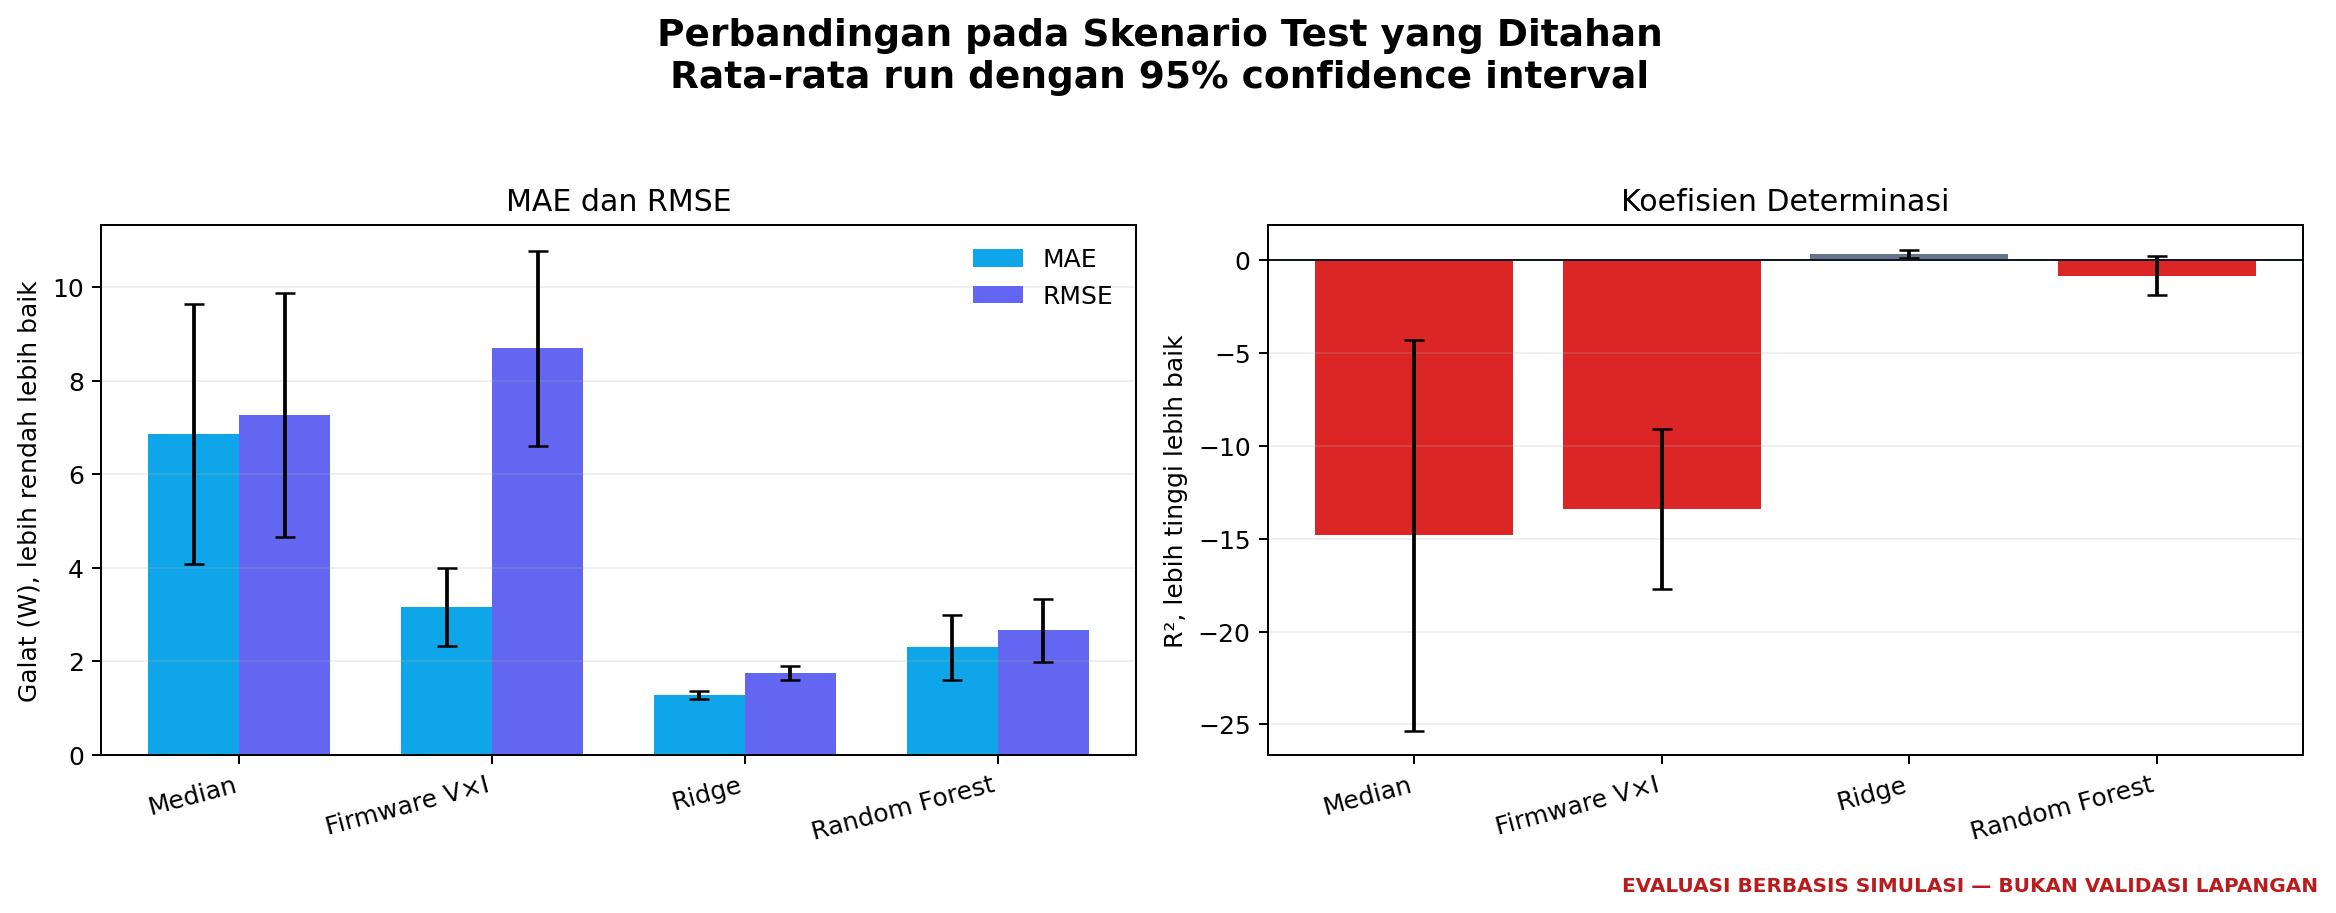

In [8]:
display(Image(filename=str(FIGURES_DIR / '03_model_comparison.png')))

### Interpretasi utama

- Ridge memberikan galat terkecil: MAE sekitar **1,277 W**.
- R² Ridge gabungan seluruh baris test adalah **0,854**, tetapi nilai ini meningkat karena perbedaan level daya antarskenario.
- Evaluasi konservatif rata-rata per-run menghasilkan R² Ridge **0,357 atau 35,7%**.
- Dengan evaluasi per-run, **tidak ada model yang mencapai 80% maupun 90%**.
- Oleh karena itu, hasil tidak boleh ditulis sebagai “akurasi Ridge 85,4%”.

## 5. Hasil per skenario test

In [9]:
scenario_rows = []
for model_id, result in models['metrics'].items():
    for scenario, metric in result['by_scenario'].items():
        scenario_rows.append({
            'Model': MODEL_LABELS[model_id],
            'Skenario': scenario,
            'MAE (W)': metric['mae_w'],
            'RMSE (W)': metric['rmse_w'],
            'R²': metric['r2'],
        })

scenario_df = pd.DataFrame(scenario_rows)
display(scenario_df.style.hide(axis='index').format({
    'MAE (W)': '{:.3f}', 'RMSE (W)': '{:.3f}', 'R²': '{:.3f}'
}))

Model,Skenario,MAE (W),RMSE (W),R²
Median train,cool_low_load,10.597,10.791,-27.057
Median train,sensor_degraded,3.113,3.754,-1.022
Firmware V×I,cool_low_load,2.130,6.160,-8.143
Firmware V×I,sensor_degraded,4.178,11.353,-17.494
Ridge,cool_low_load,1.283,1.855,0.171
Ridge,sensor_degraded,1.271,1.660,0.605
Random Forest,cool_low_load,3.257,3.570,-2.071
Random Forest,sensor_degraded,1.355,1.768,0.552


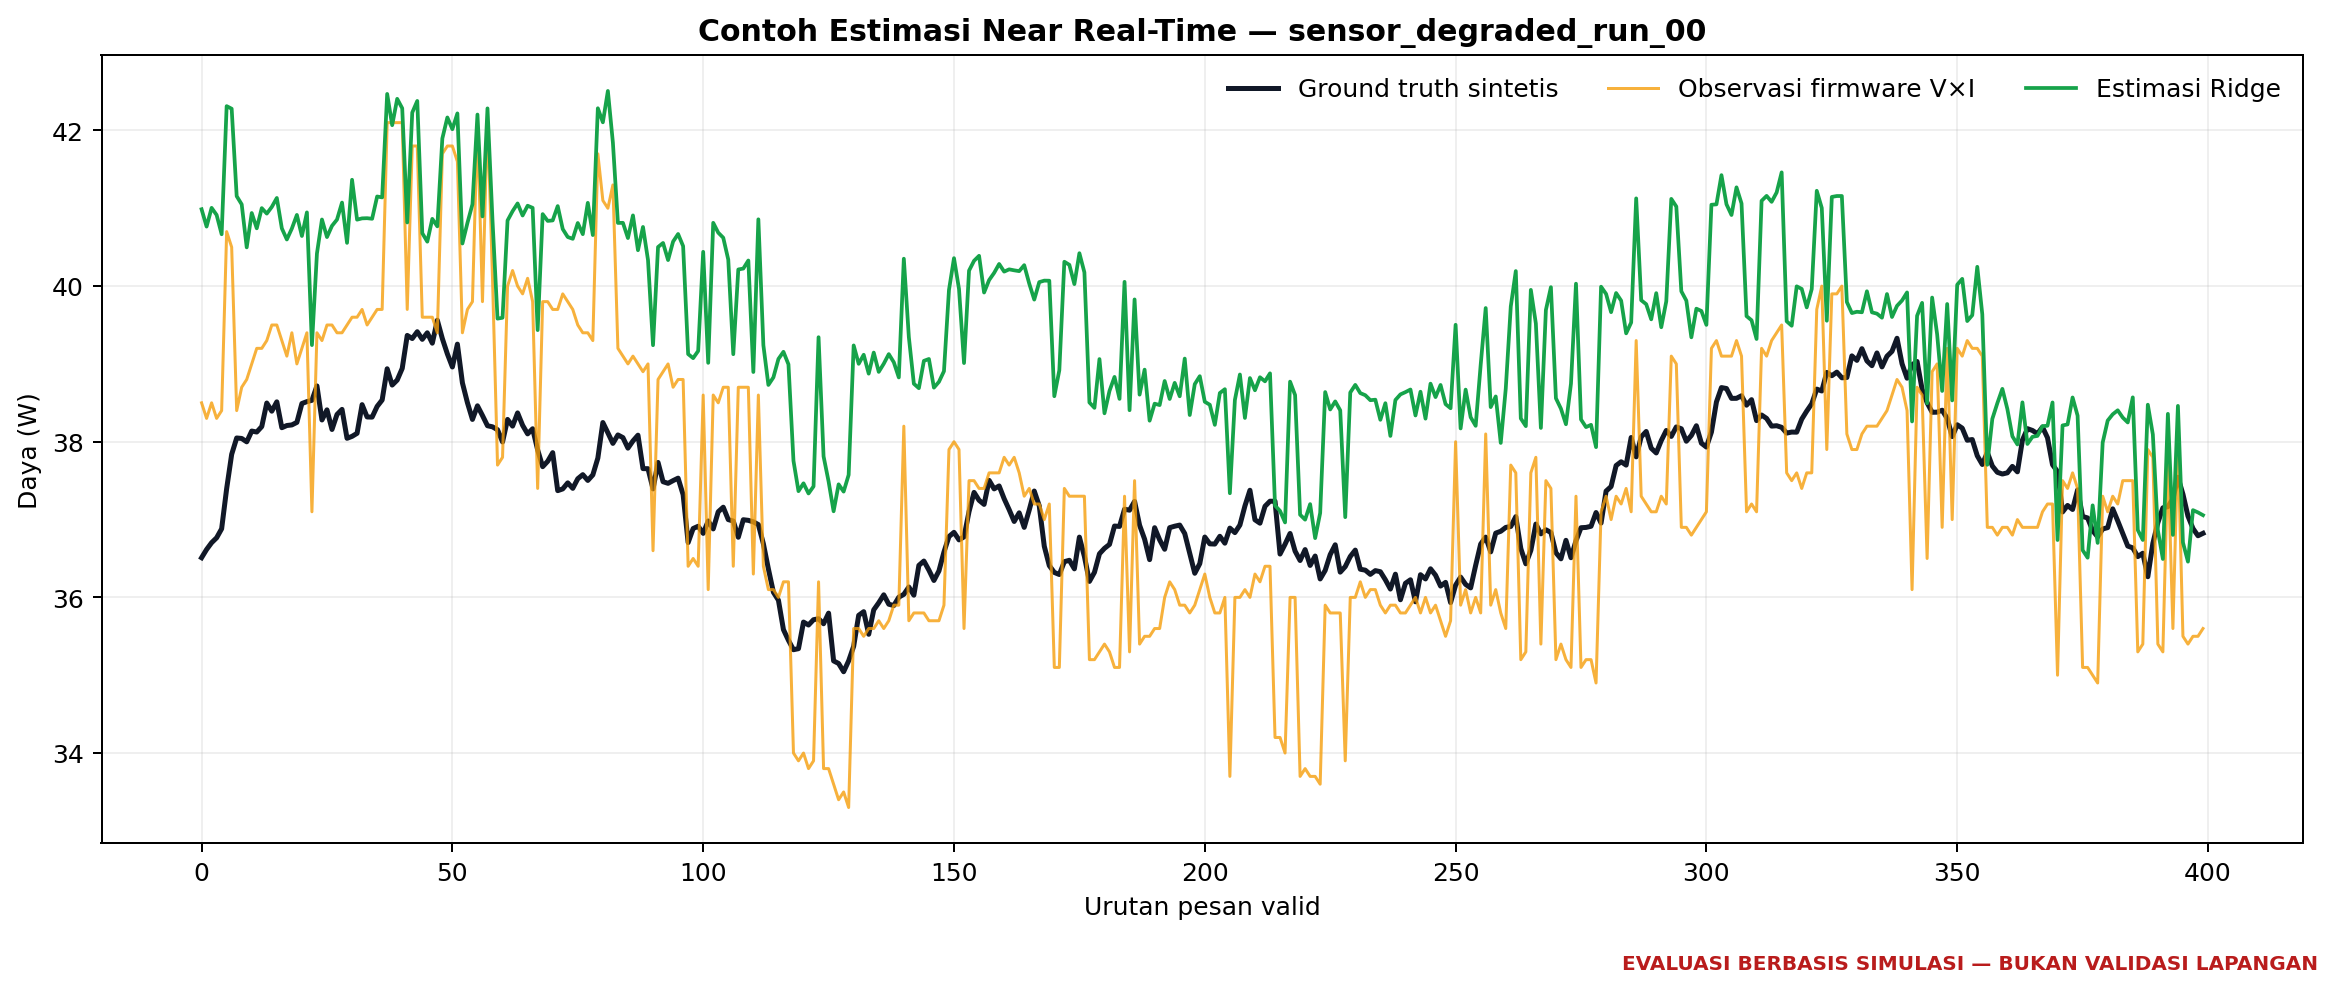

In [10]:
display(Image(filename=str(FIGURES_DIR / '02_power_timeseries.png')))

## 6. Benchmark arsitektur edge–cloud

Data augmented 2.027.520 baris ditempatkan sebagai **workload replay arsitektur**, bukan data akurasi model. Pipeline mengambil 5.000 posisi yang tersebar merata pada seluruh 22 blok replay. Inference dan serialisasi benar-benar diukur pada mesin eksperimen. Latensi jaringan/cloud berasal dari konfigurasi emulasi; bukan hasil pengukuran Azure atau public cloud.

In [11]:
workload = benchmark['scope']['workload']
routing = benchmark['routing']
workload_df = pd.DataFrame([
    ['Label sumber', workload['source_type']],
    ['Baris workload tersedia', f"{workload['available_rows']:,}"],
    ['Blok replay tercakup', len(workload['covered_replay_blocks'])],
    ['Sampel benchmark', benchmark['scope']['sample_size']],
    ['Pesan diproses di edge', routing['edge_count']],
    ['Pesan dirutekan ke cloud', routing['cloud_count']],
    ['Ambang anomali daya legacy', f"{routing['power_anomaly_threshold_w']:.1f} W"],
    ['Dipakai untuk akurasi model', 'Tidak'],
], columns=['Komponen workload', 'Nilai'])
display(workload_df.style.hide(axis='index'))

latency_rows = []
for label, key, scope in [
    ('Inference lokal', 'actual_local_compute', 'Terukur pada mesin eksperimen'),
    ('Serialisasi JSON', 'actual_json_serialization', 'Terukur pada mesin eksperimen'),
    ('Edge path', 'actual_edge_path', 'Terukur pada mesin eksperimen'),
    ('Cloud path', 'configured_cloud_path', 'Terkonfigurasi/emulasi'),
    ('Hybrid end-to-end', 'configured_end_to_end', 'Terukur + terkonfigurasi'),
]:
    metric = benchmark[key]
    latency_rows.append({
        'Jalur': label,
        'P50 (ms)': metric['p50_ms'],
        'P95 (ms)': metric['p95_ms'],
        'P99 (ms)': metric['p99_ms'],
        'Status': scope,
    })

latency_df = pd.DataFrame(latency_rows)
display(latency_df.style.hide(axis='index').format({
    'P50 (ms)': '{:.3f}', 'P95 (ms)': '{:.3f}', 'P99 (ms)': '{:.3f}'
}))

deadline = benchmark['configured_end_to_end']
display(Markdown(
    f"**Deadline:** {deadline['deadline_ms']:.0f} ms; "
    f"**deadline miss:** {deadline['deadline_miss_count']} "
    f"({100 * deadline['deadline_miss_rate']:.3f}%)."
))

Komponen workload,Nilai
Label sumber,legacy_augmented_replay
Baris workload tersedia,"2,027,520"
Blok replay tercakup,22
Sampel benchmark,5000
Pesan diproses di edge,4886
Pesan dirutekan ke cloud,114
Ambang anomali daya legacy,42.6 W
Dipakai untuk akurasi model,Tidak


Jalur,P50 (ms),P95 (ms),P99 (ms),Status
Inference lokal,2.191,6.299,11.009,Terukur pada mesin eksperimen
Serialisasi JSON,0.022,0.055,0.117,Terukur pada mesin eksperimen
Edge path,2.220,6.350,11.039,Terukur pada mesin eksperimen
Cloud path,48.386,68.037,75.852,Terkonfigurasi/emulasi
Hybrid end-to-end,2.253,7.817,50.637,Terukur + terkonfigurasi


**Deadline:** 3500 ms; **deadline miss:** 0 (0.000%).

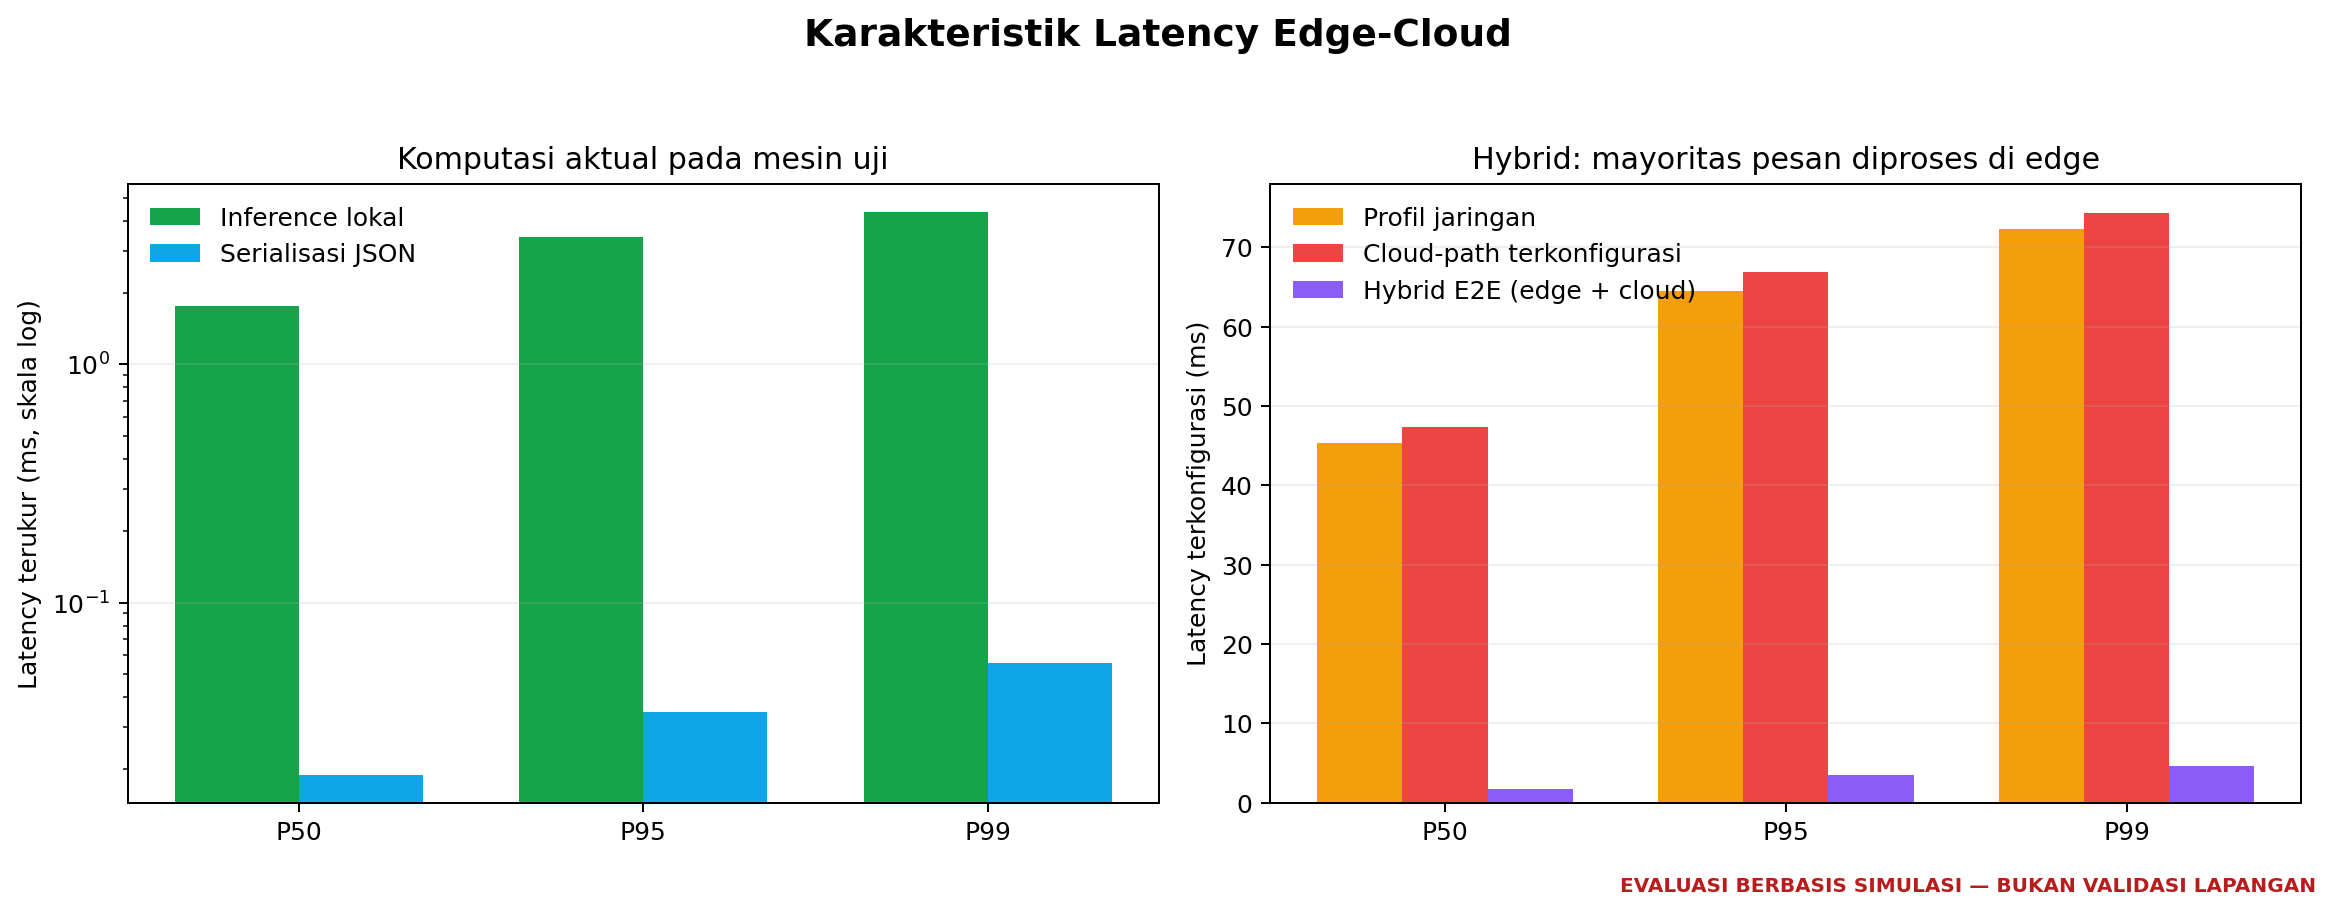

In [12]:
display(Image(filename=str(FIGURES_DIR / '04_latency_characteristics.png')))

## 7. Matriks status validasi penelitian

Tabel berikut memisahkan hal yang sudah diuji dari hal yang masih menjadi keterbatasan.

In [13]:
validation_status = pd.DataFrame([
    ['Audit trace asli dan provenance', 'Sudah', '92.160 baris, hash dan timestamp tercatat'],
    ['Kalibrasi statistik data sintetis', 'Sudah (diagnostik)', 'Lulus toleransi; bukan bukti data nyata'],
    ['Evaluasi model pada skenario sintetis tertahan', 'Sudah', 'Dilaporkan per run, skenario, dan 95% CI'],
    ['Audit workload augmented', 'Sudah', '2.027.520 baris, 22 replay; tidak masuk akurasi model'],
    ['Benchmark inference lokal', 'Sudah', 'Diukur pada MacBook/mesin eksperimen'],
    ['Alur edge-cloud', 'Sudah (emulasi)', 'Jaringan/cloud tidak diukur di produksi'],
    ['Visualisasi Digital Twin Web-3D', 'Sebagian', 'Kode/integrasi tersedia; render browser belum dibenchmark'],
    ['Ground truth daya aktif nyata independen', 'Belum', 'Data lama menggunakan V×I tanpa faktor daya'],
    ['Validasi Raspberry Pi aktif', 'Belum', 'Perangkat/sensor sudah tidak beroperasi'],
    ['Validasi public cloud nyata', 'Belum', 'Profil jaringan masih emulasi'],
    ['Validasi lapangan dan banyak bangunan', 'Belum', 'Tidak ada pengukuran prospektif baru'],
], columns=['Komponen', 'Status', 'Keterangan'])
display(validation_status.style.hide(axis='index'))

Komponen,Status,Keterangan
Audit trace asli dan provenance,Sudah,"92.160 baris, hash dan timestamp tercatat"
Kalibrasi statistik data sintetis,Sudah (diagnostik),Lulus toleransi; bukan bukti data nyata
Evaluasi model pada skenario sintetis tertahan,Sudah,"Dilaporkan per run, skenario, dan 95% CI"
Audit workload augmented,Sudah,"2.027.520 baris, 22 replay; tidak masuk akurasi model"
Benchmark inference lokal,Sudah,Diukur pada MacBook/mesin eksperimen
Alur edge-cloud,Sudah (emulasi),Jaringan/cloud tidak diukur di produksi
Visualisasi Digital Twin Web-3D,Sebagian,Kode/integrasi tersedia; render browser belum dibenchmark
Ground truth daya aktif nyata independen,Belum,Data lama menggunakan V×I tanpa faktor daya
Validasi Raspberry Pi aktif,Belum,Perangkat/sensor sudah tidak beroperasi
Validasi public cloud nyata,Belum,Profil jaringan masih emulasi


## 8. Kesimpulan yang aman untuk jurnal

> Pipeline penelitian telah selesai untuk ruang lingkup evaluasi berbasis simulasi yang dikalibrasi menggunakan trace sensor historis. Ridge menghasilkan performa terbaik dengan MAE rata-rata 1,277 W pada delapan run pengujian. Evaluasi per-run menghasilkan R² rata-rata 0,357. Data augmented 2.027.520 baris digunakan secara terpisah sebagai workload 22 replay untuk benchmark edge-cloud dan demonstrasi Digital Twin Web-3D. Benchmark menunjukkan inference lokal memenuhi target near real-time pada mesin eksperimen, sedangkan komponen jaringan/cloud masih berupa emulasi. Penelitian belum melakukan validasi lapangan menggunakan ground truth daya aktif independen.

### Hal yang tidak boleh diklaim

- “Akurasi model mencapai 85,4% atau 90%.”
- “Sistem sudah tervalidasi di lapangan.”
- “Latensi merupakan hasil pengukuran Raspberry Pi atau Azure produksi.”
- “Data sintetis merupakan dua juta observasi nyata.”

## 9. Menjalankan ulang eksperimen (opsional)

Notebook ini membaca artefak final agar cepat dibuka. Untuk mereproduksi seluruh eksperimen dari awal, jalankan perintah berikut dari terminal root proyek:

```bash
python run_experiment.py
python -m src.reporting.generate_figures --figures results/final/figures
python -m src.reporting.generate_final_report
```

Untuk pemeriksaan cepat gunakan `python run_experiment.py --rows-per-run 600`. Jangan mengganti artefak final jurnal dengan keluaran smoke test.